# EDA: Группа 3 - Топологические и структурные дескрипторы

Хакатон: ChemAI: Predict the Cure 
Группа признаков: Chi*, Kappa*, BalabanJ, BertzCT, HallKierAlpha, Ipc, FractionCSP3, RingCount, кольцевые и структурные дескрипторы 
Цель EDA: понять распределения, выявить выбросы, оценить связь с таргетами (IC50, CC50, SI), найти проблемные признаки.

---

### Что такое топологические дескрипторы?

- Chi-индексы (χ) - индексы молекулярной связности Рандича. Описывают ветвление и размер молекулы через взвешенные суммы по путям в молекулярном графе.
- Kappa-индексы (κ) - индексы формы Киера. κ1 связан с гибкостью, κ2 - со степенью ветвления, κ3 - с симметрией.
- BalabanJ - индекс Балабана, мера разветвлённости на основе матрицы расстояний.
- BertzCT - мера сложности молекулы Берца.
- HallKierAlpha - поправочный параметр Холла–Кира к χ-индексам.
- Ipc / AvgIpc - информационный индекс сложности молекулы.
- FractionCSP3 - доля sp^3-гибридизованных атомов углерода (насыщенность).
- RingCount и Ring-дескрипторы - количество и тип колец (ароматические, алифатические, насыщенные).
- NumRotatableBonds - количество вращаемых связей (гибкость молекулы).


## 1. Импорты и настройки

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.feature_selection import VarianceThreshold, mutual_info_regression
from sklearn.preprocessing import StandardScaler
import warnings

warnings.filterwarnings('ignore')
plt.style.use('ggplot')
sns.set_palette('viridis')
%matplotlib inline

SEED = 42
np.random.seed(SEED)
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.4f}'.format)

## 2. Загрузка данных

In [2]:
train = pd.read_csv('Данные/train.csv')
test = pd.read_csv('Данные/test.csv')

# Переименуем колонки таргетов для удобства
train.rename(columns={'IC50, mM': 'IC50', 'CC50, mM': 'CC50'}, inplace=True)

print(f'Train: {train.shape} | Test: {test.shape}')
train.head(3)

Train: (751, 214) | Test: (250, 211)


,index,IC50,CC50,SI,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,HeavyAtomMolWt,ExactMolWt,NumValenceElectrons,NumRadicalElectrons,MaxPartialCharge,MinPartialCharge,MaxAbsPartialCharge,MinAbsPartialCharge,FpDensityMorgan1,FpDensityMorgan2,FpDensityMorgan3,BCUT2D_MWHI,BCUT2D_MWLOW,BCUT2D_CHGHI,...,fr_nitro_arom_nonortho,fr_nitroso,fr_oxazole,fr_oxime,fr_para_hydroxylation,fr_phenol,fr_phenol_noOrthoHbond,fr_phos_acid,fr_phos_ester,fr_piperdine,fr_piperzine,fr_priamide,fr_prisulfonamd,fr_pyridine,fr_quatN,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,0,102.4144,95.7575,0.9350,5.4666,5.4666,0.7193,0.7193,0.6812,18.3077,195.2870,182.1830,195.0718,70,0,0.1192,-0.3602,0.3602,0.1192,1.2308,2.0769,2.9231,32.1665,10.2919,2.0828,...,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0
1,1,0.0443,8.4011,189.5000,11.4927,11.4927,0.0124,-3.7980,0.7691,27.6522,360.9070,335.7070,360.1274,130,0,0.2377,-0.3931,0.3931,0.2377,1.3043,1.9565,2.5217,35.4957,9.6315,2.4001,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0
2,2,4.4380,50.0856,11.2857,5.3661,5.3661,0.5229,0.5229,0.6126,24.6087,315.4570,286.2250,315.2198,126,0,0.1605,-0.4929,0.4929,0.1605,1.1739,1.9565,2.6087,16.5078,9.4867,2.5022,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


## 3. Признаки группы 3

In [3]:
GROUP_NAME = 'Топологические и структурные дескрипторы'
TARGETS = ['IC50', 'CC50', 'SI']

FEATURES = [
 # Chi-индексы связности (Randic)
 'Chi0', 'Chi0n', 'Chi0v',
 'Chi1', 'Chi1n', 'Chi1v',
 'Chi2n', 'Chi2v',
 'Chi3n', 'Chi3v',
 'Chi4n', 'Chi4v',
 # Kappa-индексы формы (Kier)
 'Kappa1', 'Kappa2', 'Kappa3',
 # Прочие топологические
 'BalabanJ', 'BertzCT', 'HallKierAlpha',
 'Ipc', 'AvgIpc',
 # Структурные / кольцевые
 'FractionCSP3', 'RingCount',
 'NumAliphaticCarbocycles', 'NumAliphaticHeterocycles', 'NumAliphaticRings',
 'NumAromaticCarbocycles', 'NumAromaticHeterocycles', 'NumAromaticRings',
 'NumSaturatedCarbocycles', 'NumSaturatedHeterocycles', 'NumSaturatedRings',
 'NumRotatableBonds',
]

# Убеждаемся, что все признаки есть в данных
missing_in_df = [f for f in FEATURES if f not in train.columns]
print('Признаков в группе:', len(FEATURES))
print('Отсутствующих в датасете:', missing_in_df if missing_in_df else 'нет')

Признаков в группе: 32
Отсутствующих в датасете: нет


## 4. Базовая статистика

In [4]:
desc = train[FEATURES].describe().T
desc['skewness'] = train[FEATURES].skew()
desc['kurtosis'] = train[FEATURES].kurt()
desc['cv'] = desc['std'] / desc['mean'].abs() # коэффициент вариации
desc.round(3)

,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis,cv
Chi0,751.0000,17.8650,6.4010,5.5600,13.6470,16.4390,20.7060,45.7640,0.9640,0.6700,0.3580
Chi0n,751.0000,14.6820,5.1960,4.1120,11.3010,13.5300,16.5860,35.9870,1.1180,1.1950,0.3540
Chi0v,751.0000,15.0160,5.2980,4.1120,11.5060,13.8710,16.9790,35.9870,1.0760,1.0270,0.3530
Chi1,751.0000,11.8820,4.5020,3.8600,8.9690,10.5550,14.0400,29.8010,0.9890,0.4980,0.3790
Chi1n,751.0000,8.7460,3.1330,2.1290,6.8140,7.9830,9.9700,22.2130,1.2100,1.6640,0.3580
Chi1v,751.0000,9.0470,3.2330,2.1290,6.9130,8.2350,10.4390,22.2130,1.1190,1.2490,0.3570
Chi2n,751.0000,7.3860,2.7180,1.3010,5.5570,6.8300,8.6680,20.1810,1.2860,2.5710,0.3680
Chi2v,751.0000,7.7310,2.8110,1.3010,5.7900,7.3250,9.0950,20.1810,1.1030,1.7080,0.3640
Chi3n,751.0000,5.6730,2.4250,0.7500,4.0880,5.2010,6.7030,16.4770,1.5630,3.9840,0.4280
Chi3v,751.0000,5.9650,2.4930,0.7500,4.3300,5.5860,7.0310,16.4770,1.3590,2.9090,0.4180


## 5. Анализ пропусков

In [5]:
missing_pct = (train[FEATURES].isnull().sum() / len(train) * 100).sort_values(ascending=False)
missing_df = missing_pct[missing_pct > 0]

if len(missing_df) == 0:
 print(' Пропуски в группе отсутствуют.')
else:
 print('Признаки с пропусками:')
 print(missing_df)
 fig, ax = plt.subplots(figsize=(10, 3))
 missing_df.plot(kind='bar', ax=ax, color='tomato')
 ax.set_title('Доля пропусков по признакам, %')
 ax.set_ylabel('%')
 plt.tight_layout()
 plt.show()

 Пропуски в группе отсутствуют.


## 6. Распределения признаков

Гистограммы с KDE для всех 32 признаков группы.

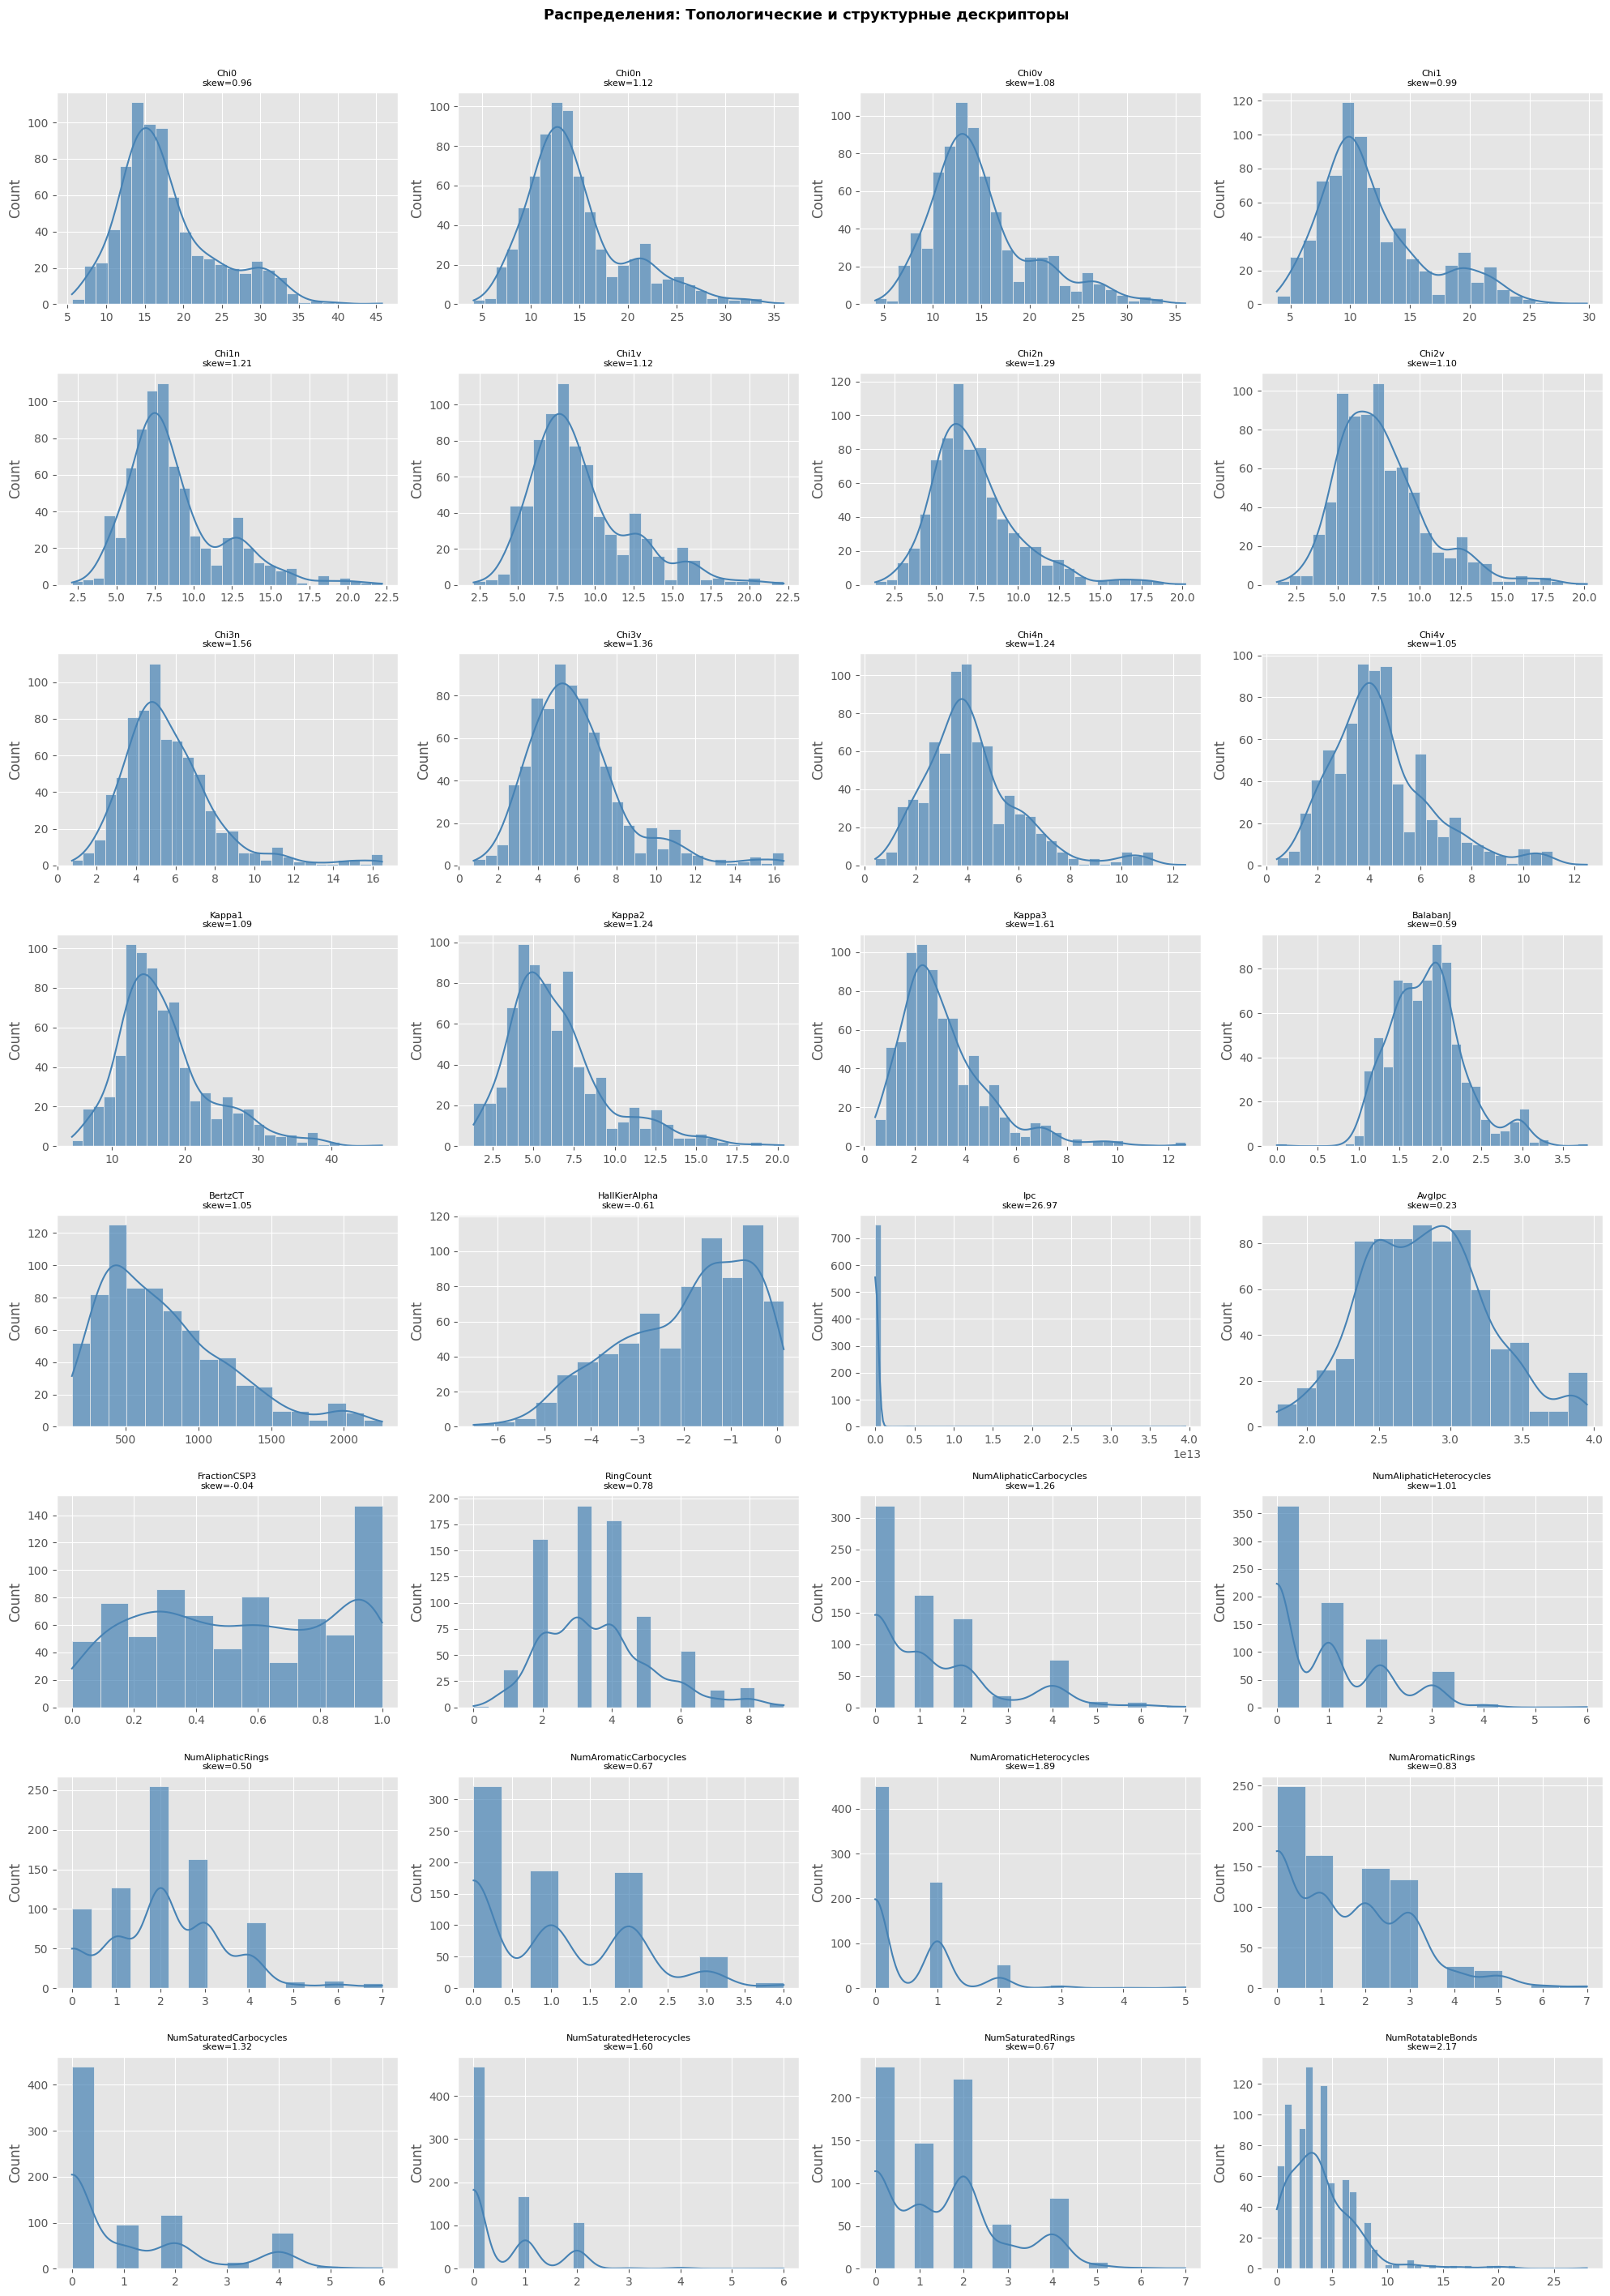

In [6]:
n_cols = 4
n_rows = int(np.ceil(len(FEATURES) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 3.5 * n_rows))
axes = axes.flatten()

for i, feat in enumerate(FEATURES):
 ax = axes[i]
 data = train[feat].dropna()
 sns.histplot(data, kde=True, ax=ax, color='steelblue', alpha=0.7)
 skew = data.skew()
 ax.set_title(f'{feat}\nskew={skew:.2f}', fontsize=8)
 ax.set_xlabel('')

for j in range(i + 1, len(axes)):
 fig.delaxes(axes[j])

fig.suptitle(f'Распределения: {GROUP_NAME}', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 7. Боксплоты и выбросы (IQR)

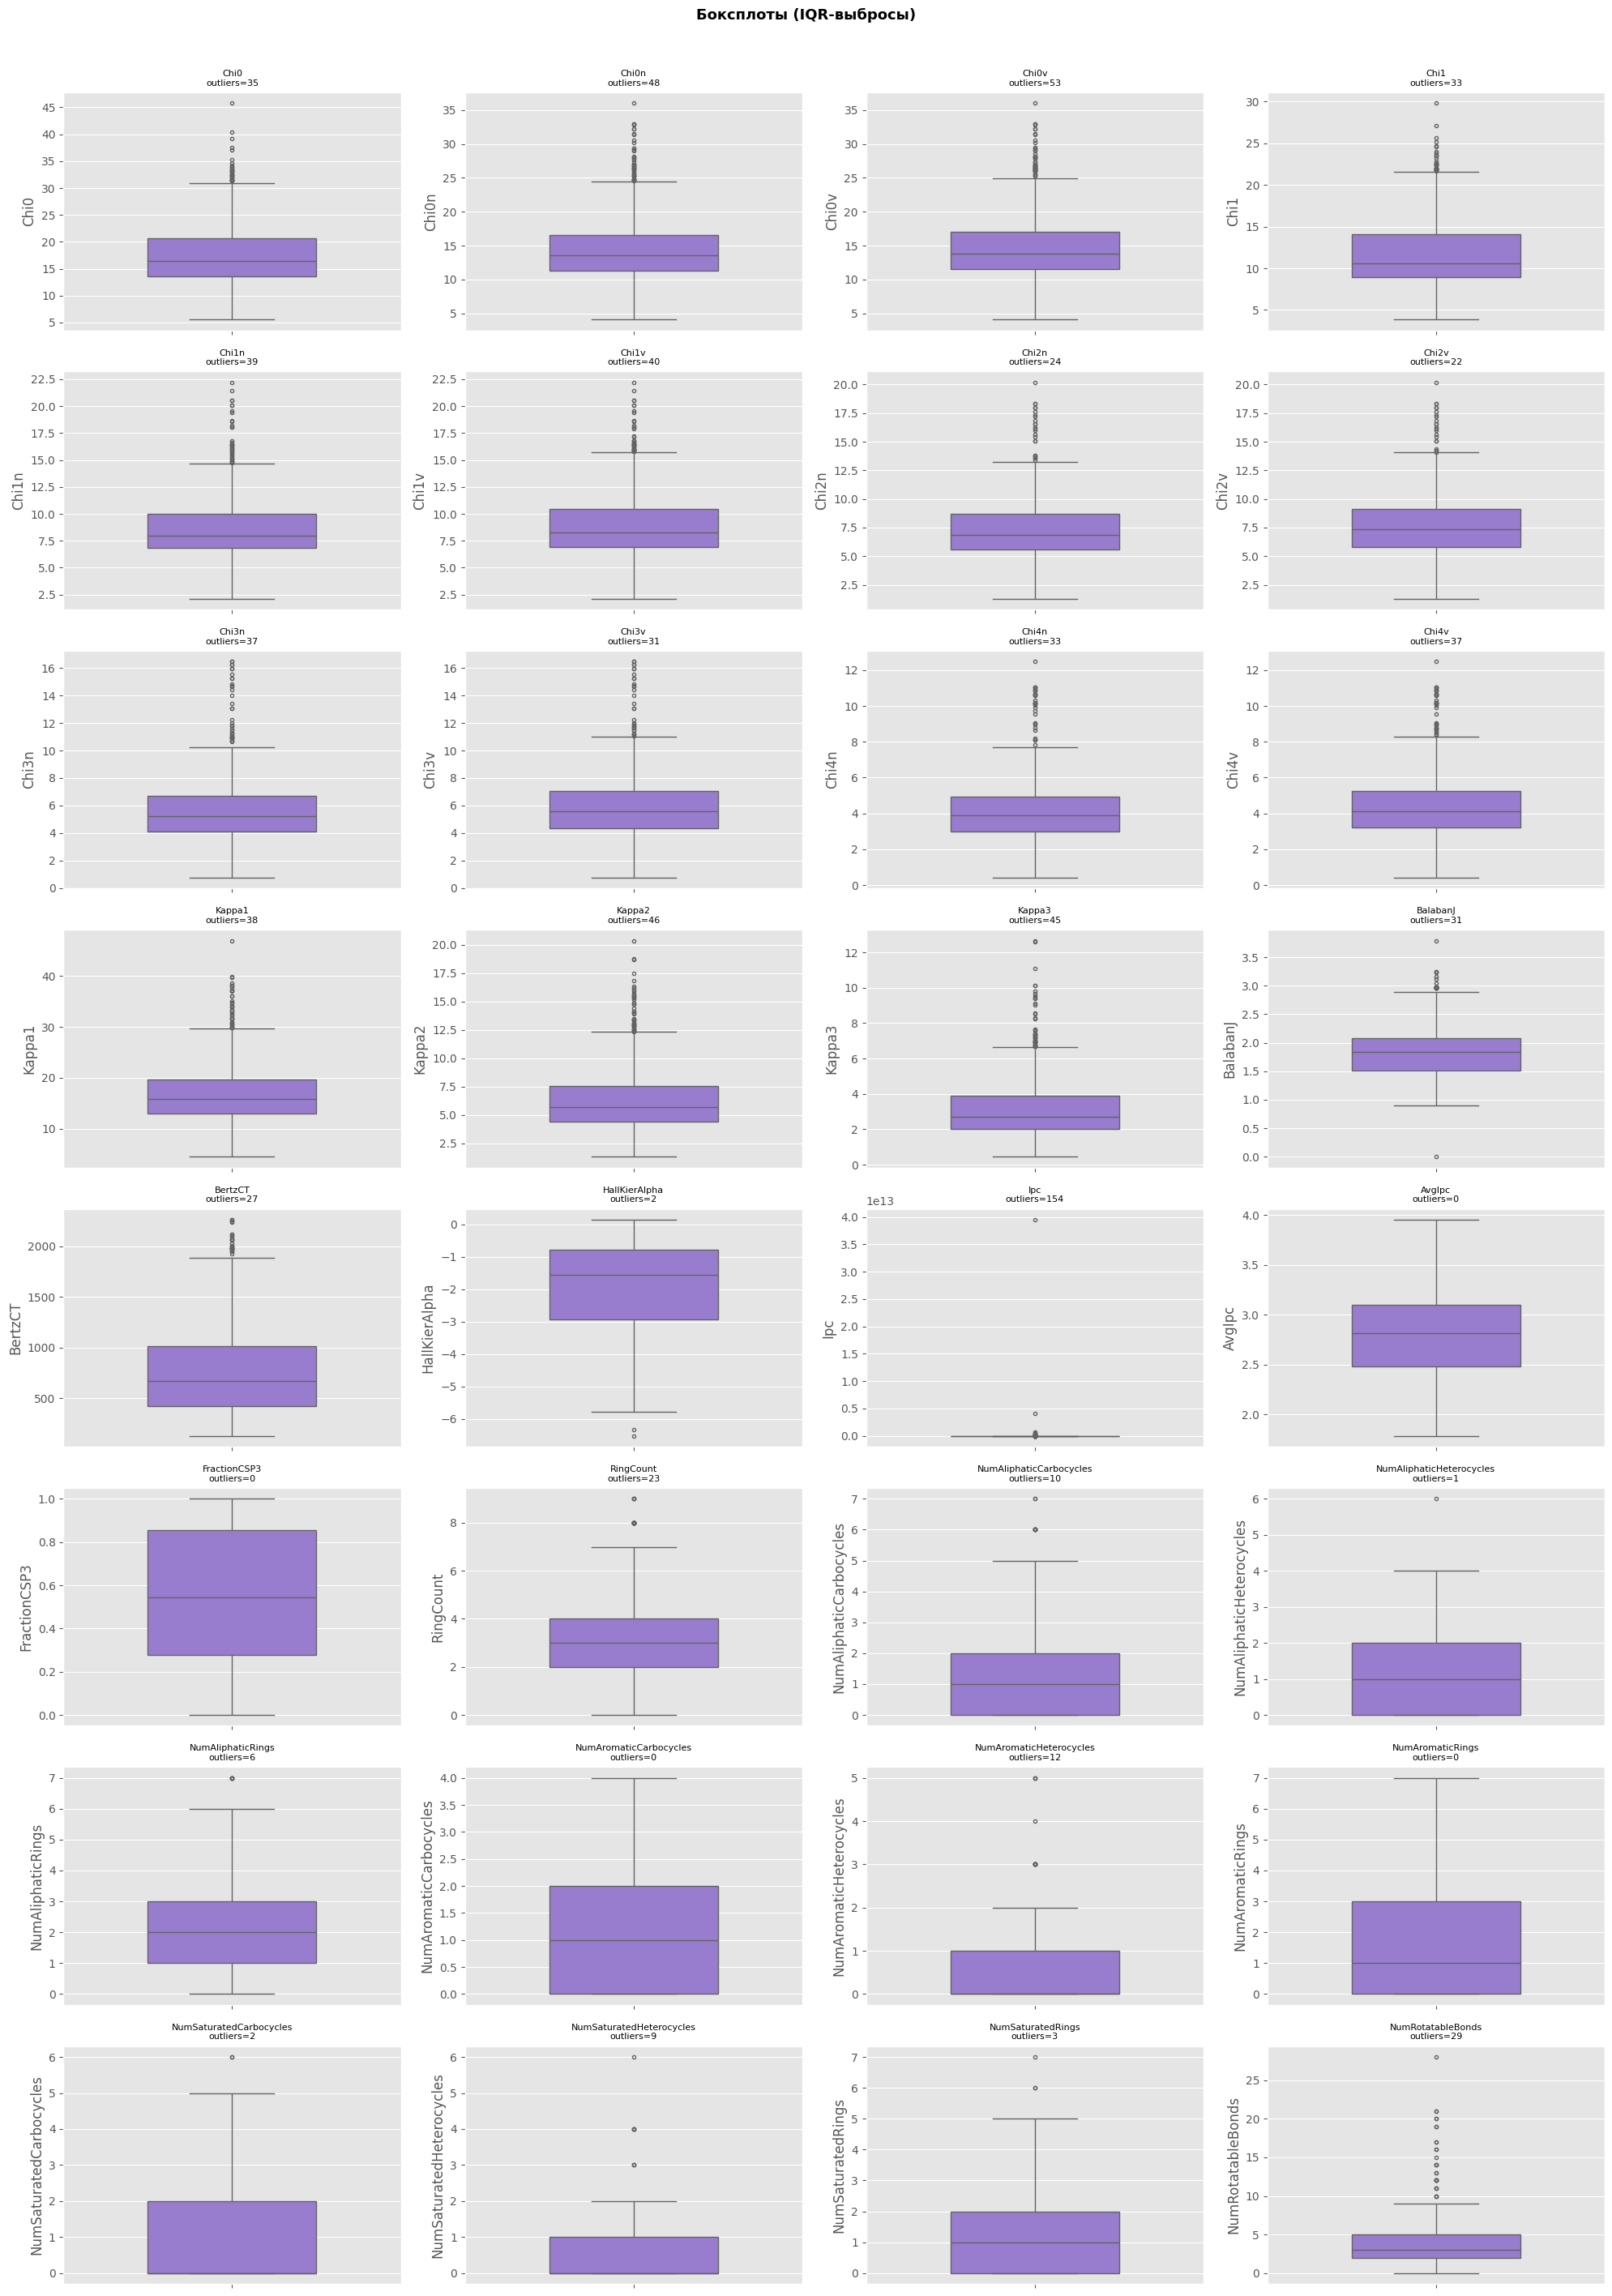

Топ-10 признаков по числу выбросов (IQR):
Ipc       154
Chi0v      53
Chi0n      48
Kappa2     46
Kappa3     45
Chi1v      40
Chi1n      39
Kappa1     38
Chi3n      37
Chi4v      37


In [7]:
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 3.5 * n_rows))
axes = axes.flatten()

outlier_summary = {}
for i, feat in enumerate(FEATURES):
 ax = axes[i]
 data = train[feat].dropna()
 q1, q3 = data.quantile(0.25), data.quantile(0.75)
 iqr = q3 - q1
 n_out = ((data < q1 - 1.5 * iqr) | (data > q3 + 1.5 * iqr)).sum()
 outlier_summary[feat] = n_out
 sns.boxplot(y=data, ax=ax, color='mediumpurple', width=0.5, fliersize=3)
 ax.set_title(f'{feat}\noutliers={n_out}', fontsize=8)
 ax.set_xlabel('')

for j in range(i + 1, len(axes)):
 fig.delaxes(axes[j])

fig.suptitle('Боксплоты (IQR-выбросы)', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# Таблица выбросов
out_df = pd.Series(outlier_summary, name='outliers').sort_values(ascending=False)
print('Топ-10 признаков по числу выбросов (IQR):')
print(out_df.head(10).to_string())

## 8. Логарифмирование: до и после

Признаки с асимметрией |skew| > 1 - кандидаты на log1p-трансформацию.

Признаков с |skew| > 1: 21
['Chi0n', 'Chi0v', 'Chi1n', 'Chi1v', 'Chi2n', 'Chi2v', 'Chi3n', 'Chi3v', 'Chi4n', 'Chi4v', 'Kappa1', 'Kappa2', 'Kappa3', 'BertzCT', 'Ipc', 'NumAliphaticCarbocycles', 'NumAliphaticHeterocycles', 'NumAromaticHeterocycles', 'NumSaturatedCarbocycles', 'NumSaturatedHeterocycles', 'NumRotatableBonds']


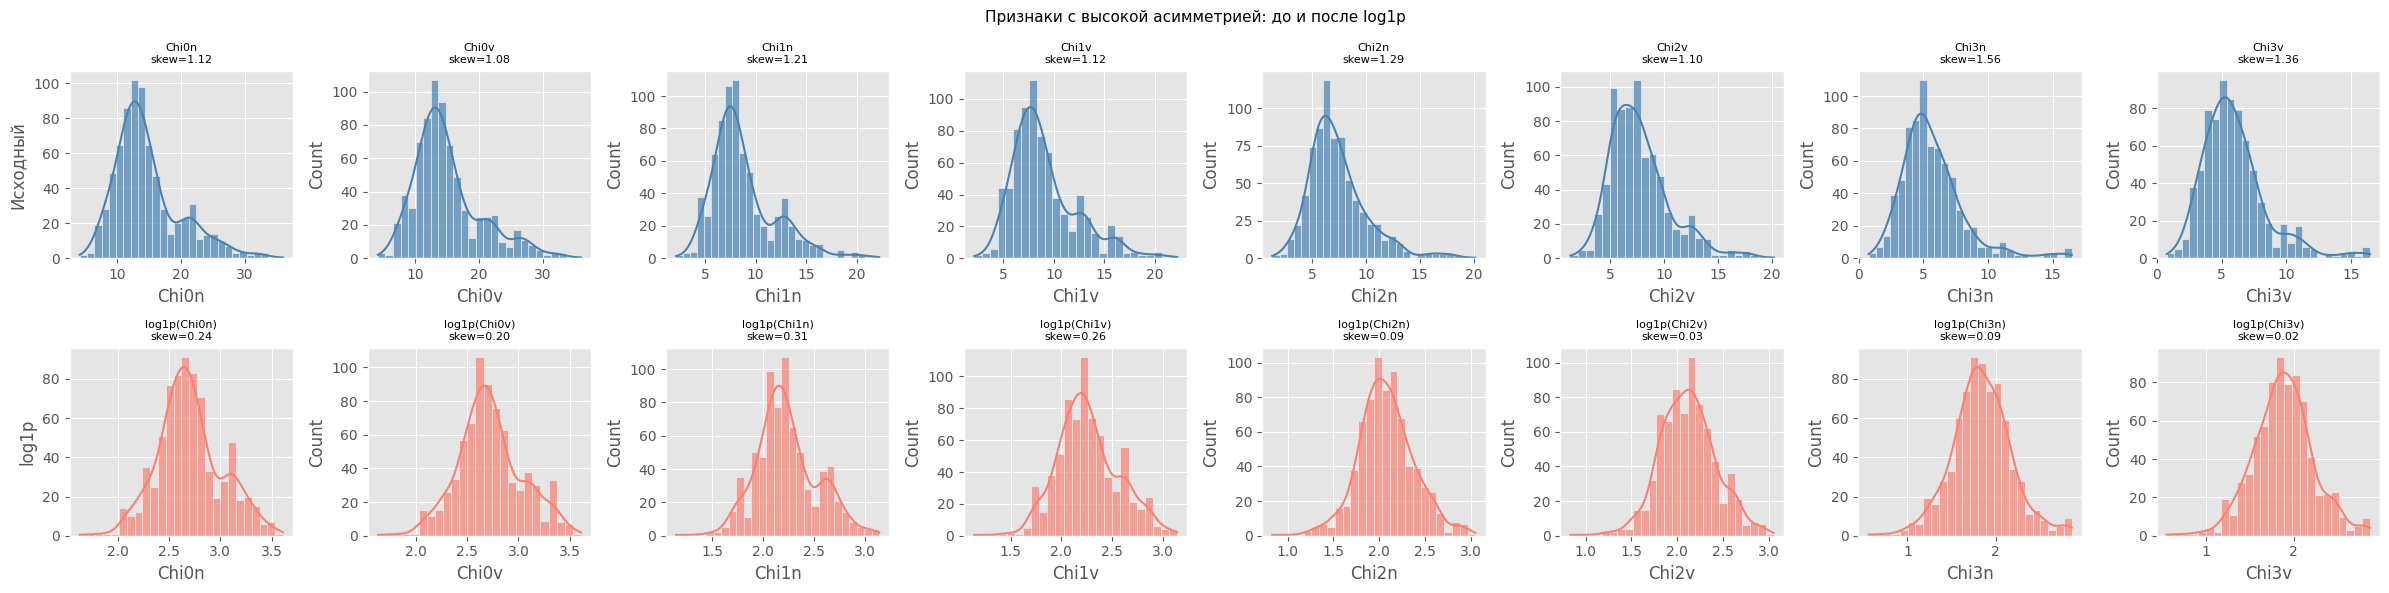

In [8]:
high_skew = [f for f in FEATURES if abs(train[f].skew()) > 1]
print(f'Признаков с |skew| > 1: {len(high_skew)}')
print(high_skew)

if high_skew:
    n_show = min(len(high_skew), 8)
    fig, axes = plt.subplots(2, n_show, figsize=(3 * n_show, 6))
    for i, feat in enumerate(high_skew[:n_show]):
        data = train[feat].dropna()
        offset = max(0, -data.min()) + 1e-6
        sns.histplot(data, kde=True, ax=axes[0, i], color='steelblue', alpha=0.7)
        axes[0, i].set_title(f'{feat}\nskew={data.skew():.2f}', fontsize=8)
        log_data = np.log1p(data + offset)
        sns.histplot(log_data, kde=True, ax=axes[1, i], color='salmon', alpha=0.7)
        axes[1, i].set_title(f'log1p({feat})\nskew={log_data.skew():.2f}', fontsize=8)
    axes[0, 0].set_ylabel('Исходный')
    axes[1, 0].set_ylabel('log1p')
    plt.suptitle('Признаки с высокой асимметрией: до и после log1p', fontsize=11)
    plt.tight_layout()
    plt.show()


## 9. Корреляционный анализ внутри группы

Тепловая карта помогает выявить мультиколлинеарность между признаками.

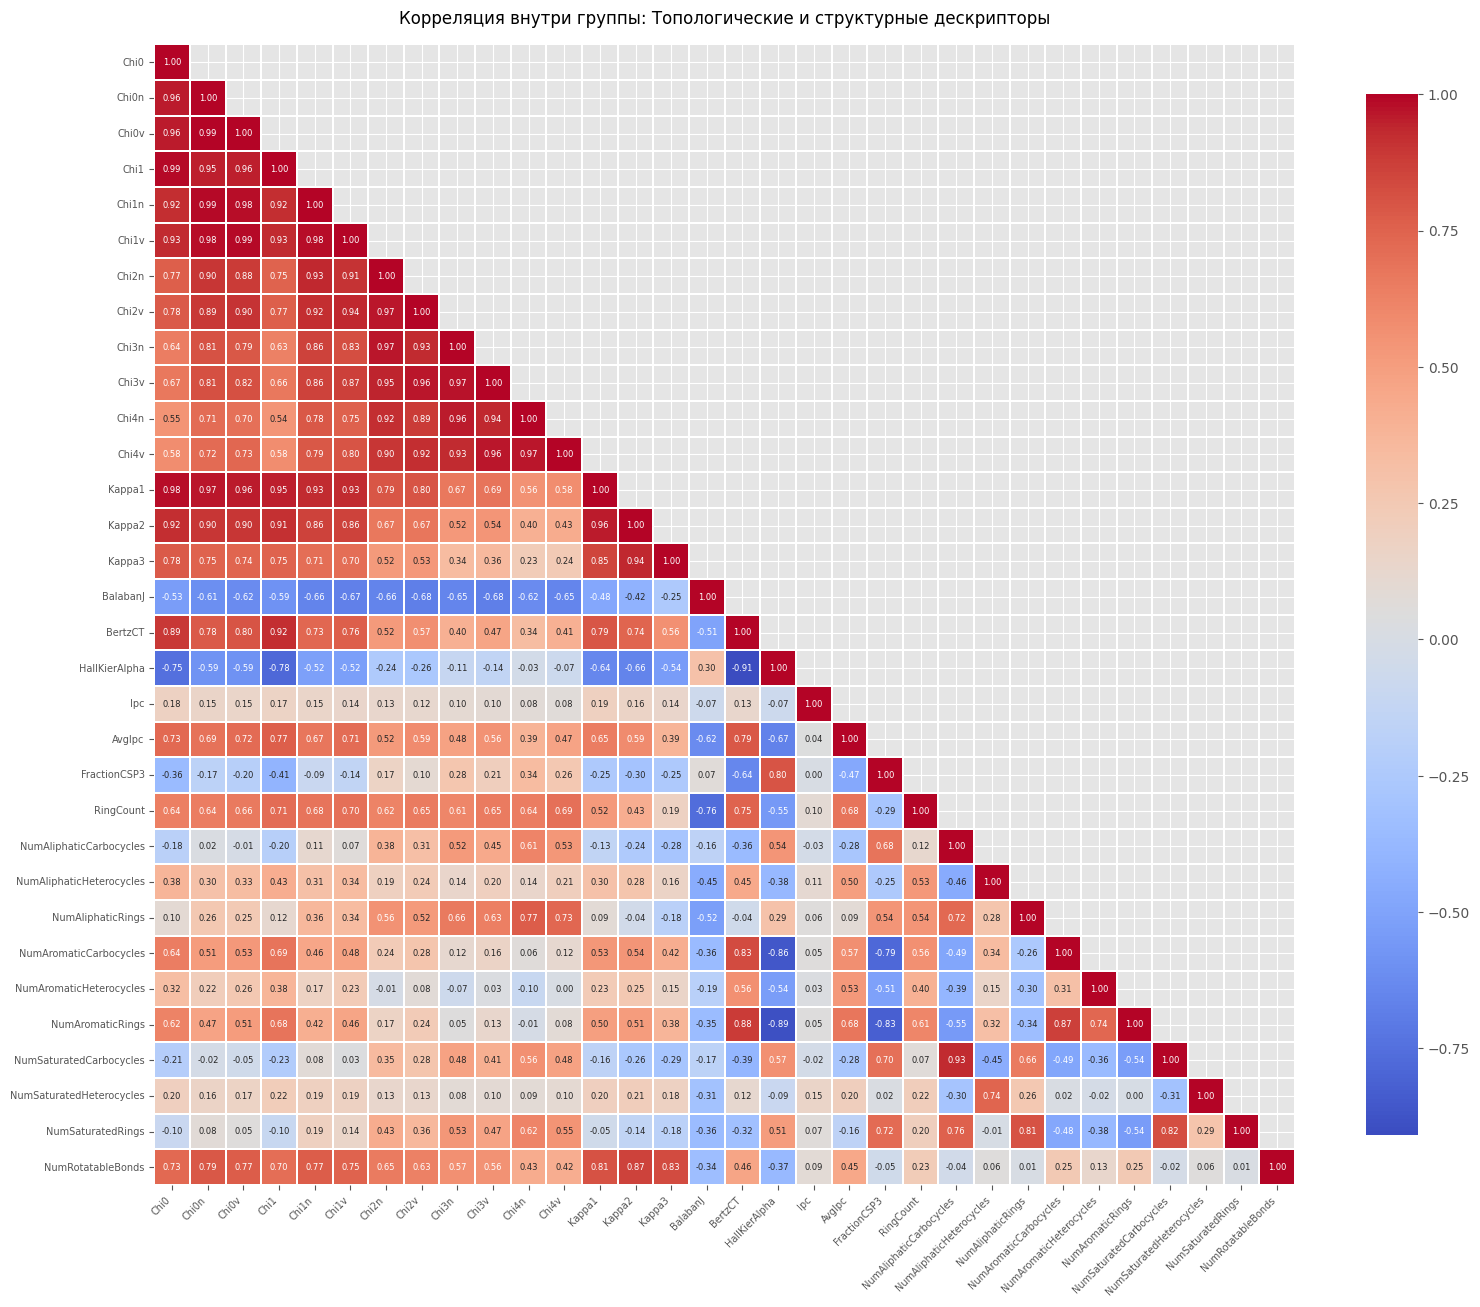

In [9]:
corr_inner = train[FEATURES].corr()

fig, ax = plt.subplots(figsize=(16, 14))
mask = np.triu(np.ones_like(corr_inner, dtype=bool), k=1)
sns.heatmap(
 corr_inner, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
 linewidths=0.3, square=True, cbar_kws={'shrink': 0.8},
 annot_kws={'size': 6}, ax=ax
)
ax.set_title(f'Корреляция внутри группы: {GROUP_NAME}', fontsize=12, pad=15)
ax.set_xticklabels(ax.get_xticklabels(), fontsize=7, rotation=45, ha='right')
ax.set_yticklabels(ax.get_yticklabels(), fontsize=7)
plt.tight_layout()
plt.show()

## 10. Корреляция признаков с таргетами (IC50, CC50, SI)

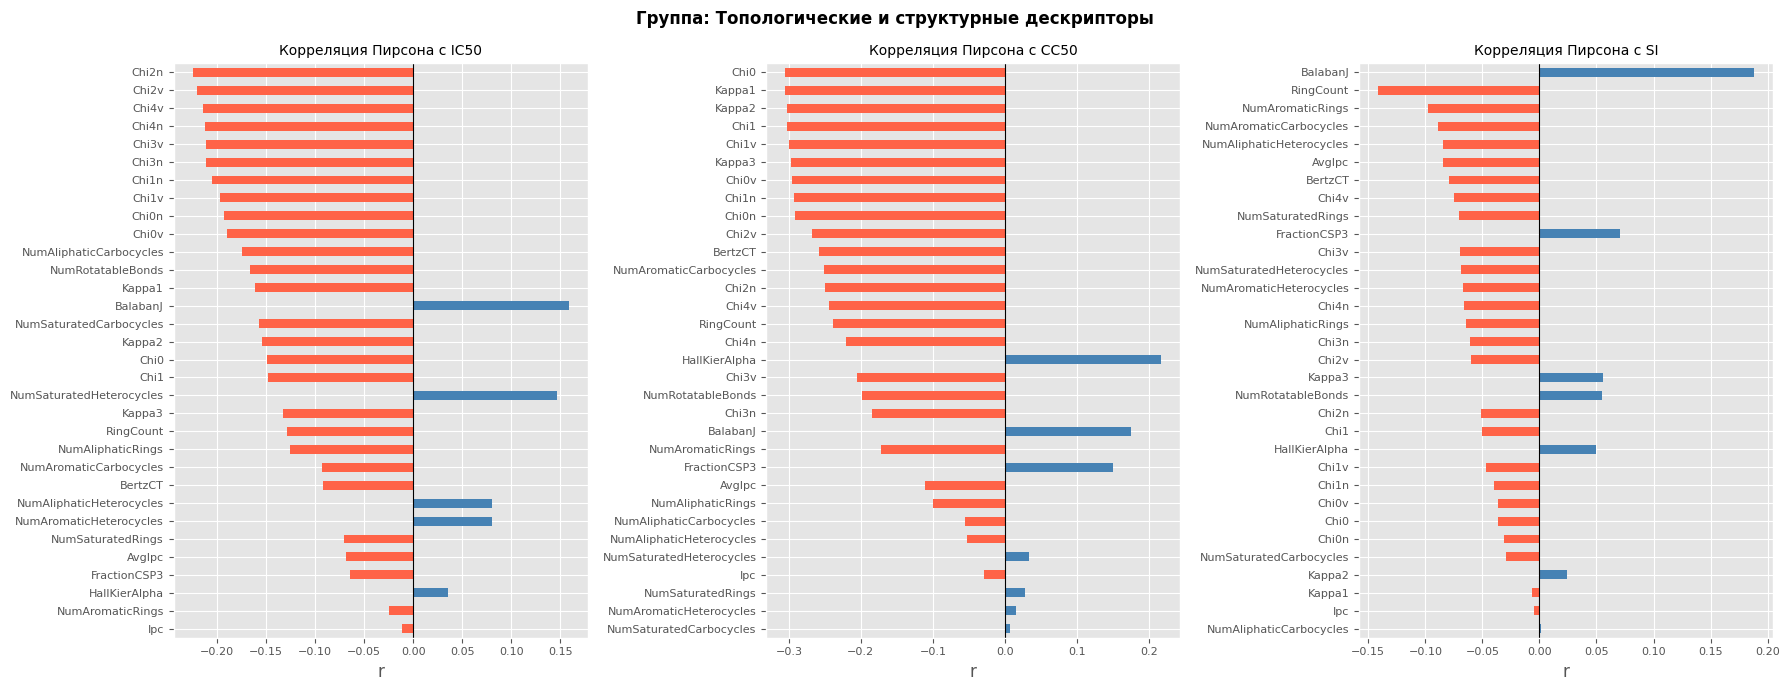


Топ-5 по |r| с IC50:
  Chi2n                           r = -0.2249
  Chi2v                           r = -0.2204
  Chi4v                           r = -0.2142
  Chi4n                           r = -0.2118
  Chi3v                           r = -0.2114

Топ-5 по |r| с CC50:
  Chi0                            r = -0.3051
  Kappa1                          r = -0.3048
  Kappa2                          r = -0.3028
  Chi1                            r = -0.3024
  Chi1v                           r = -0.3004

Топ-5 по |r| с SI:
  BalabanJ                        r = 0.1882
  RingCount                       r = -0.1417
  NumAromaticRings                r = -0.0976
  NumAromaticCarbocycles          r = -0.0888
  NumAliphaticHeterocycles        r = -0.0847


In [10]:
corr_all = train[FEATURES + TARGETS].corr()

fig, axes = plt.subplots(1, 3, figsize=(18, 7))
for ax, target in zip(axes, TARGETS):
    corr_t = corr_all[target][FEATURES].sort_values(key=abs, ascending=True)
    colors = ['tomato' if v < 0 else 'steelblue' for v in corr_t]
    corr_t.plot(kind='barh', ax=ax, color=colors)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(f'Корреляция Пирсона с {target}', fontsize=10)
    ax.set_xlabel('r')
    ax.tick_params(labelsize=8)

plt.suptitle(f'Группа: {GROUP_NAME}', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

for target in TARGETS:
    top5 = corr_all[target][FEATURES].abs().sort_values(ascending=False).head(5)
    print(f'\nТоп-5 по |r| с {target}:')
    for feat, val in top5.items():
        direction = corr_all[target][feat]
        print(f'  {feat:30s}  r = {direction:.4f}')


## 11. Корреляция Спирмена (ранговая - устойчива к выбросам)

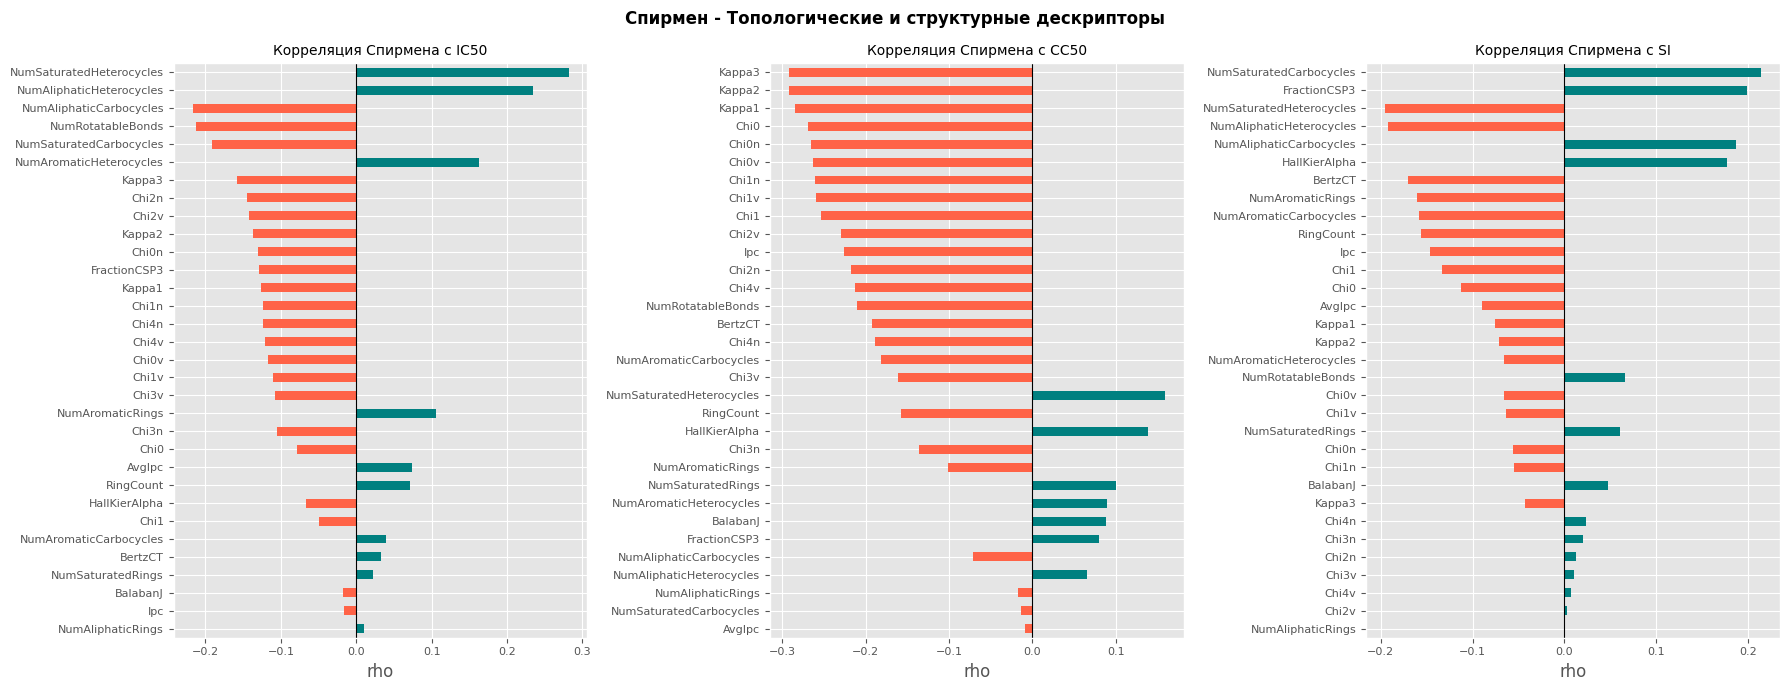

In [11]:
spearman_corr = train[FEATURES + TARGETS].corr(method='spearman')

fig, axes = plt.subplots(1, 3, figsize=(18, 7))
for ax, target in zip(axes, TARGETS):
    corr_t = spearman_corr[target][FEATURES].sort_values(key=abs, ascending=True)
    colors = ['tomato' if v < 0 else 'teal' for v in corr_t]
    corr_t.plot(kind='barh', ax=ax, color=colors)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(f'Корреляция Спирмена с {target}', fontsize=10)
    ax.set_xlabel('rho')
    ax.tick_params(labelsize=8)

plt.suptitle(f'Спирмен - {GROUP_NAME}', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


## 12. Scatter-plots: топ-признаки vs таргеты

Топ-6 признаков по средней |r| с таргетами: ['Chi2v', 'Chi1v', 'Chi1n', 'Chi4v', 'Chi2n', 'BalabanJ']


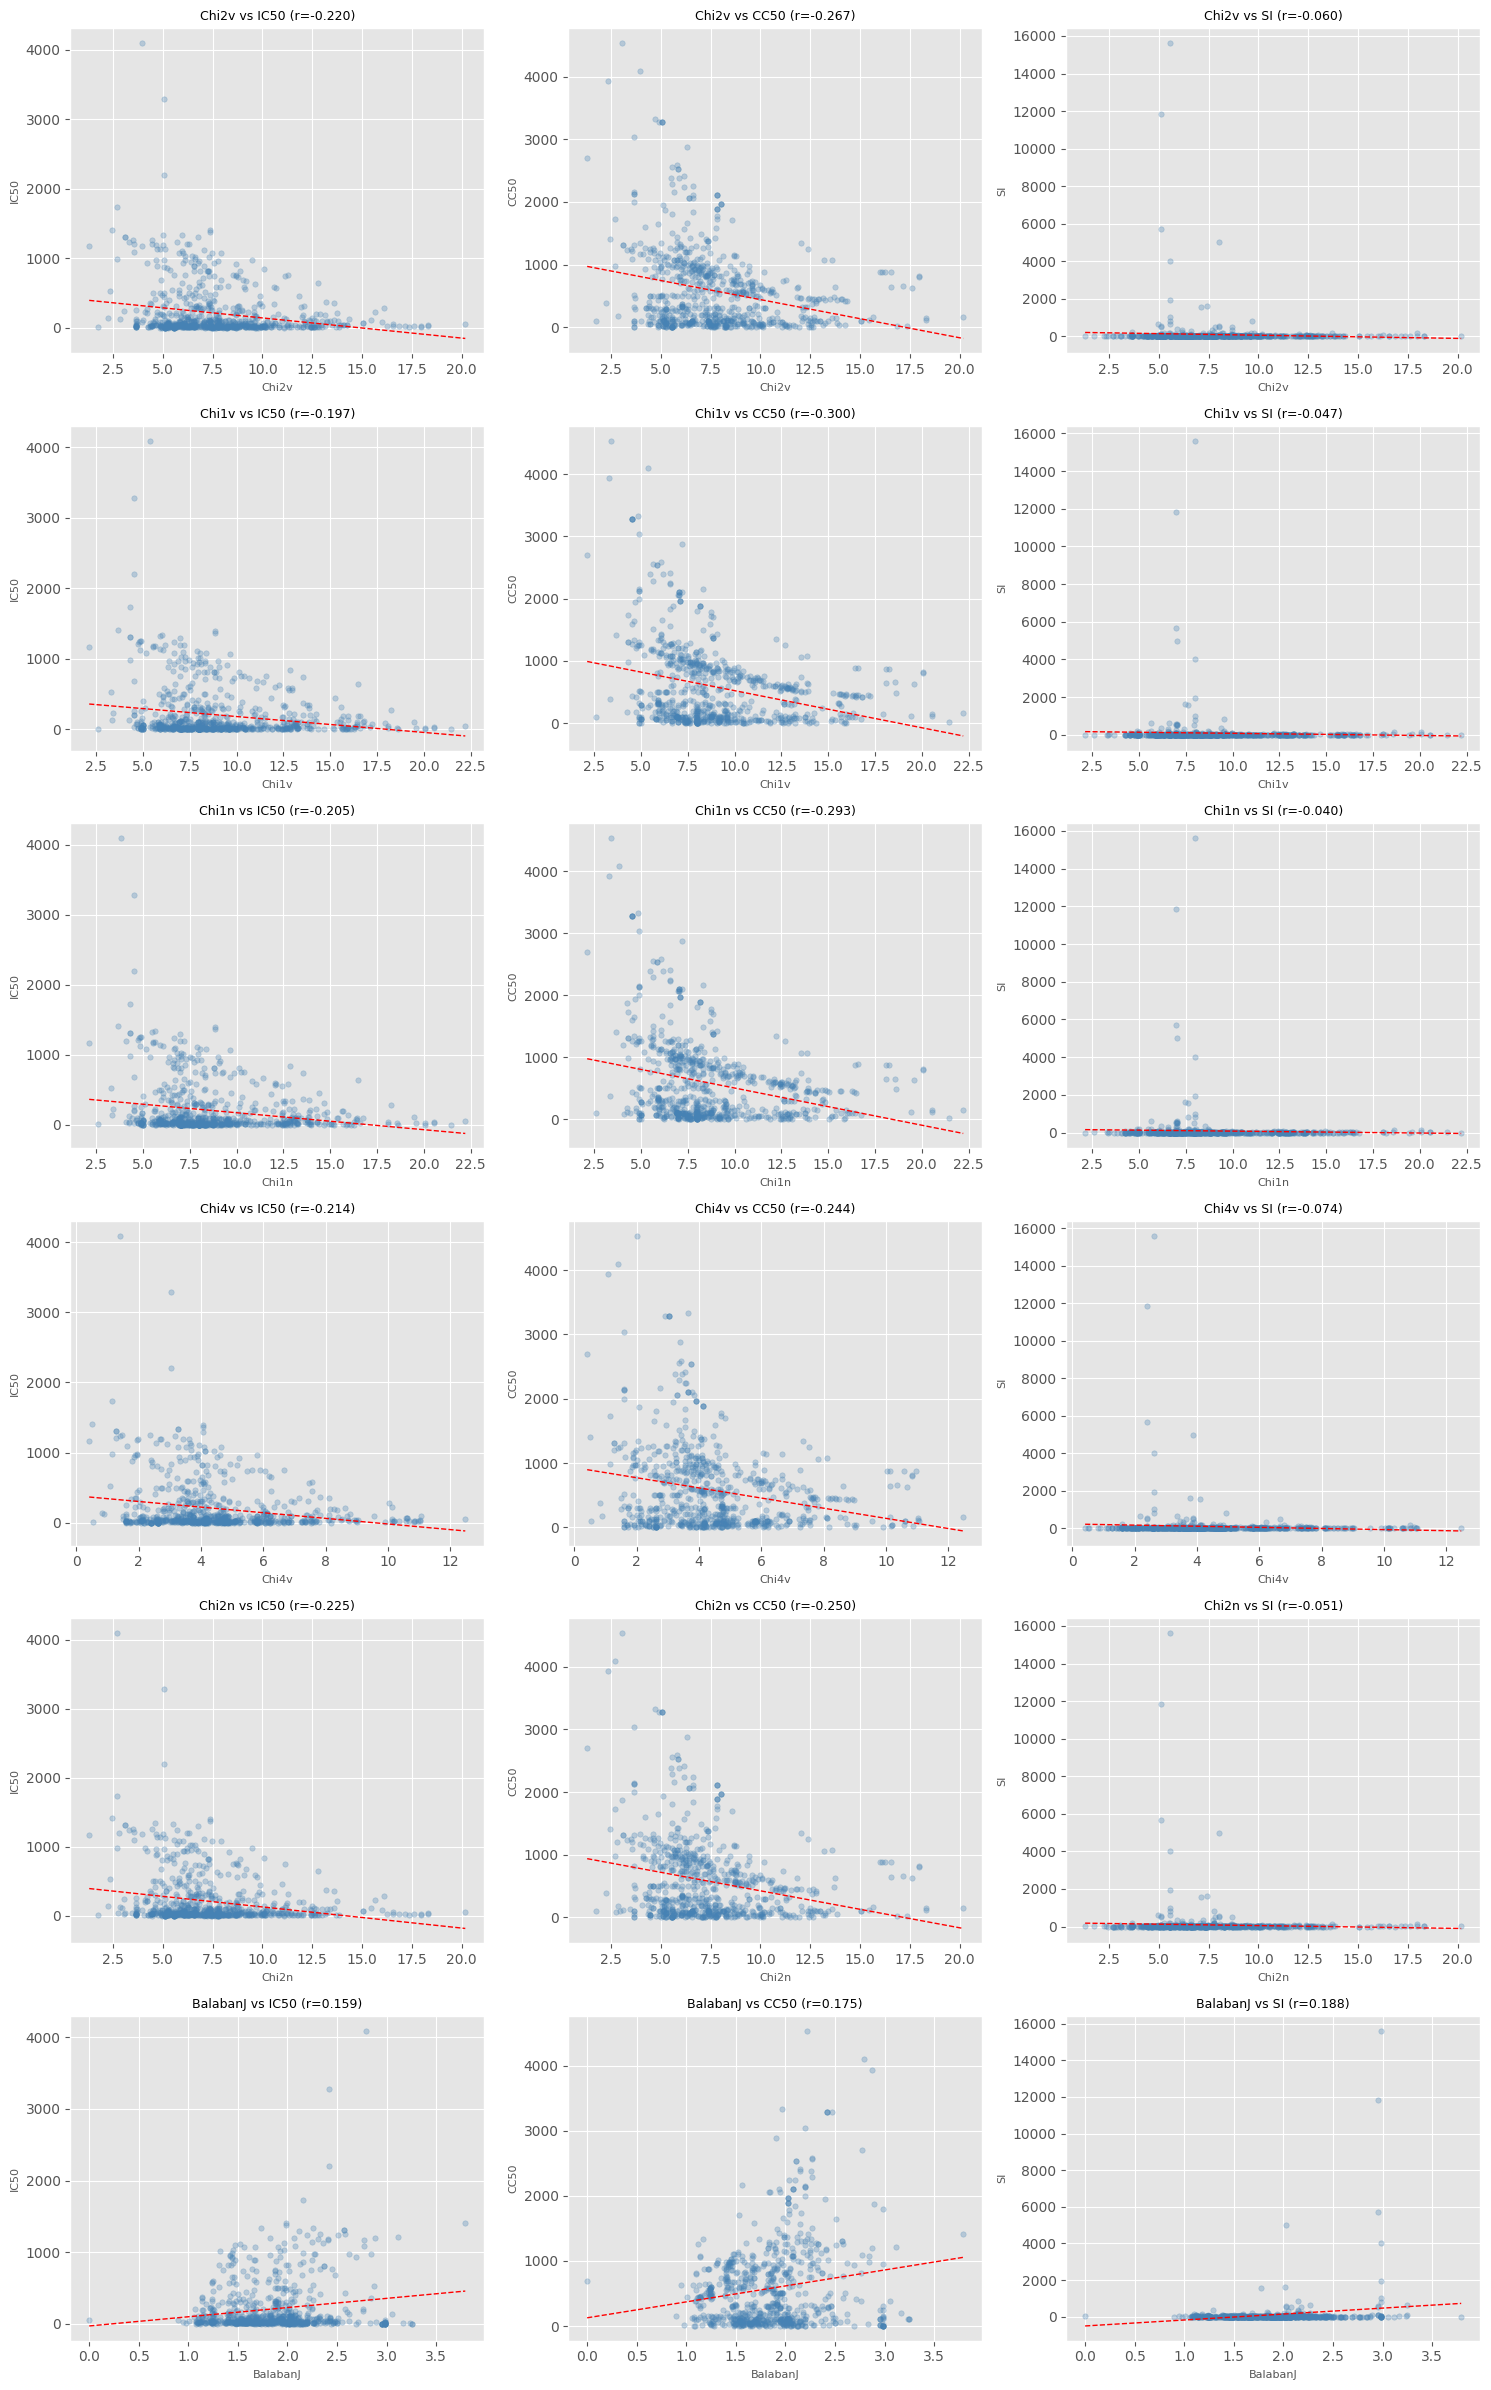

In [12]:
mean_abs_corr = corr_all[TARGETS].loc[FEATURES].abs().mean(axis=1).sort_values(ascending=False)
top_features = mean_abs_corr.head(6).index.tolist()
print('Топ-6 признаков по средней |r| с таргетами:', top_features)

fig, axes = plt.subplots(len(top_features), 3, figsize=(15, 4 * len(top_features)))
for i, feat in enumerate(top_features):
    for j, target in enumerate(TARGETS):
        ax = axes[i, j]
        ax.scatter(train[feat], train[target], alpha=0.3, s=15, color='steelblue')
        x_clean = train[feat].dropna()
        y_clean = train[target][x_clean.index].dropna()
        x_c = x_clean[y_clean.index]
        if len(x_c) > 2:
            z = np.polyfit(x_c, y_clean, 1)
            p = np.poly1d(z)
            x_line = np.linspace(x_c.min(), x_c.max(), 100)
            ax.plot(x_line, p(x_line), 'r--', linewidth=1)
        r_val = corr_all[target][feat]
        ax.set_xlabel(feat, fontsize=8)
        ax.set_ylabel(target, fontsize=8)
        ax.set_title(f'{feat} vs {target} (r={r_val:.3f})', fontsize=9)

plt.tight_layout()
plt.show()


## 13. Взаимная информация (Mutual Information)

В отличие от корреляции, MI улавливает нелинейные зависимости.

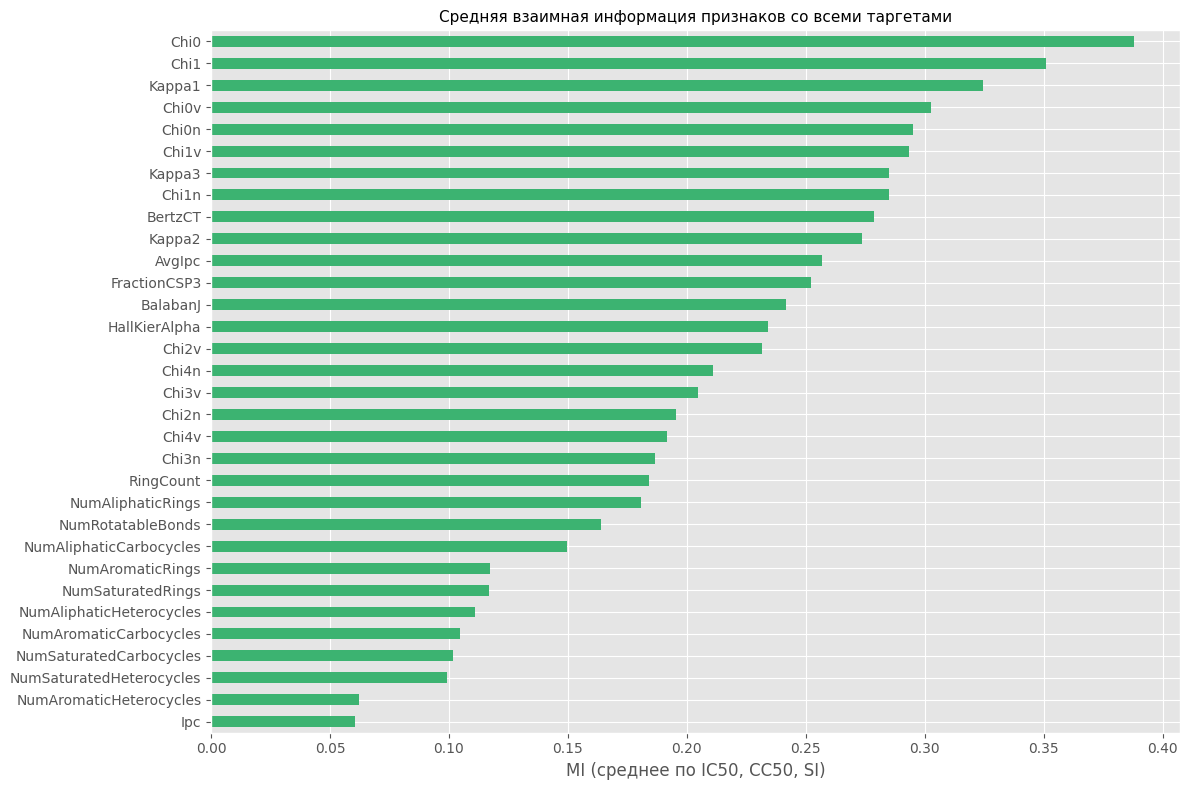


Топ-10 по средней MI:
Chi0      0.3879
Chi1      0.3508
Kappa1    0.3243
Chi0v     0.3028
Chi0n     0.2951
Chi1v     0.2935
Kappa3    0.2849
Chi1n     0.2848
BertzCT   0.2787
Kappa2    0.2737


In [13]:
from sklearn.feature_selection import mutual_info_regression

X = train[FEATURES].fillna(train[FEATURES].median())

mi_results = {}
for target in TARGETS:
 y = train[target].fillna(train[target].median())
 mi = mutual_info_regression(X, y, random_state=SEED)
 mi_results[target] = pd.Series(mi, index=FEATURES)

mi_df = pd.DataFrame(mi_results)
mi_df['mean_MI'] = mi_df.mean(axis=1)
mi_df = mi_df.sort_values('mean_MI', ascending=False)

fig, ax = plt.subplots(figsize=(12, 8))
mi_df['mean_MI'].sort_values().plot(kind='barh', ax=ax, color='mediumseagreen')
ax.set_title('Средняя взаимная информация признаков со всеми таргетами', fontsize=11)
ax.set_xlabel('MI (среднее по IC50, CC50, SI)')
plt.tight_layout()
plt.show()

print('\nТоп-10 по средней MI:')
print(mi_df['mean_MI'].head(10).round(4).to_string())

## 14. Проблемные признаки

Проверяем:
- константные и почти константные (variance → 0)
- дублирующиеся (высокая мультиколлинеарность, |r| > 0.95)

In [14]:
# Константные
constant_feats = [f for f in FEATURES if train[f].std() == 0]
print(f'Константные признаки (std=0): {constant_feats if constant_feats else "нет"}')

# Почти константные (CV < 0.01)
low_cv = []
for f in FEATURES:
    mean_v = train[f].mean()
    if mean_v != 0:
        cv = train[f].std() / abs(mean_v)
        if cv < 0.01:
            low_cv.append((f, round(cv, 5)))
print(f'Почти константные (CV < 0.01): {low_cv if low_cv else "нет"}')

# Пары с высокой корреляцией (|r| > 0.95)
corr_abs = train[FEATURES].corr().abs()
upper = corr_abs.where(np.triu(np.ones(corr_abs.shape), k=1).astype(bool))
high_corr_pairs = [
    (col, row, upper.loc[row, col])
    for col in upper.columns
    for row in upper.index
    if pd.notna(upper.loc[row, col]) and upper.loc[row, col] > 0.95
]

if high_corr_pairs:
    print(f'\nПары с |r| > 0.95 ({len(high_corr_pairs)} пар):')
    for a, b, r in sorted(high_corr_pairs, key=lambda x: -x[2]):
        print(f'  {a:30s} - {b:30s}  r = {r:.4f}')
else:
    print('\nПар с |r| > 0.95 не обнаружено.')


Константные признаки (std=0): нет
Почти константные (CV < 0.01): нет

Пары с |r| > 0.95 (22 пар):
  Chi0v                          - Chi0n                           r = 0.9927
  Chi1                           - Chi0                            r = 0.9908
  Chi1n                          - Chi0n                           r = 0.9890
  Chi1v                          - Chi0v                           r = 0.9882
  Chi1v                          - Chi1n                           r = 0.9838
  Chi1n                          - Chi0v                           r = 0.9799
  Kappa1                         - Chi0                            r = 0.9798
  Chi1v                          - Chi0n                           r = 0.9777
  Chi3v                          - Chi3n                           r = 0.9722
  Chi2v                          - Chi2n                           r = 0.9700
  Chi3n                          - Chi2n                           r = 0.9655
  Chi4v                          - Chi4n    

## 15. Подгрупповой анализ

Разобьём признаки на смысловые подгруппы и сравним их информативность.

=== Средняя |корреляция Пирсона| по подгруппам ===
                  Признаков  mean|r| с IC50  mean|r| с CC50  mean|r| с SI
Подгруппа                                                                
Chi (связность)          12          0.1978          0.2633        0.0519
Kappa (форма)             3          0.1492          0.3016        0.0289
Прочие топол.             5          0.0731          0.1580        0.0811
Кольца/структура         12          0.1093          0.1084        0.0699


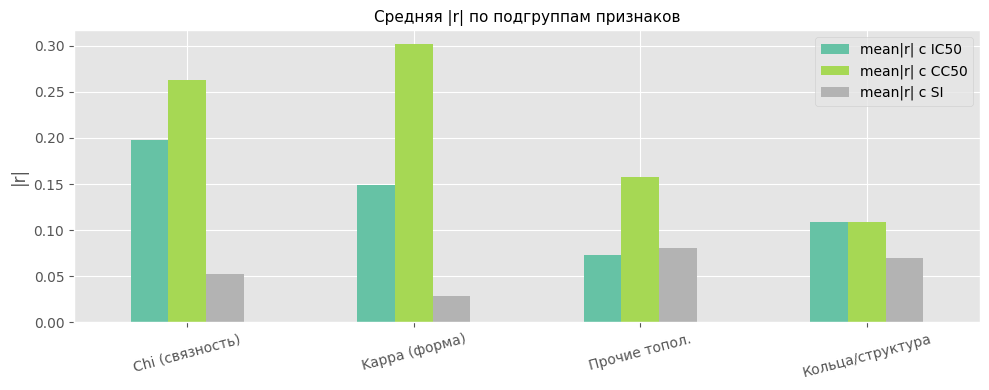

In [15]:
subgroups = {
    'Chi (связность)': [f for f in FEATURES if f.startswith('Chi')],
    'Kappa (форма)':   [f for f in FEATURES if f.startswith('Kappa')],
    'Прочие топол.':   ['BalabanJ', 'BertzCT', 'HallKierAlpha', 'Ipc', 'AvgIpc'],
    'Кольца/структура': ['FractionCSP3', 'RingCount',
                          'NumAliphaticCarbocycles', 'NumAliphaticHeterocycles', 'NumAliphaticRings',
                          'NumAromaticCarbocycles',  'NumAromaticHeterocycles',  'NumAromaticRings',
                          'NumSaturatedCarbocycles', 'NumSaturatedHeterocycles', 'NumSaturatedRings',
                          'NumRotatableBonds'],
}

print('=== Средняя |корреляция Пирсона| по подгруппам ===')
rows = []
for name, feats in subgroups.items():
    row = {'Подгруппа': name, 'Признаков': len(feats)}
    for t in TARGETS:
        row[f'mean|r| с {t}'] = corr_all[t][feats].abs().mean()
    rows.append(row)

sg_df = pd.DataFrame(rows).set_index('Подгруппа')
print(sg_df.round(4).to_string())

fig, ax = plt.subplots(figsize=(10, 4))
sg_df[[f'mean|r| с {t}' for t in TARGETS]].plot(kind='bar', ax=ax, colormap='Set2')
ax.set_title('Средняя |r| по подгруппам признаков', fontsize=11)
ax.set_ylabel('|r|')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=15)
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()


## 16. Детальный анализ кольцевых дескрипторов

Смотрим, как распределяется количество колец разного типа в молекулах обучающей выборки.

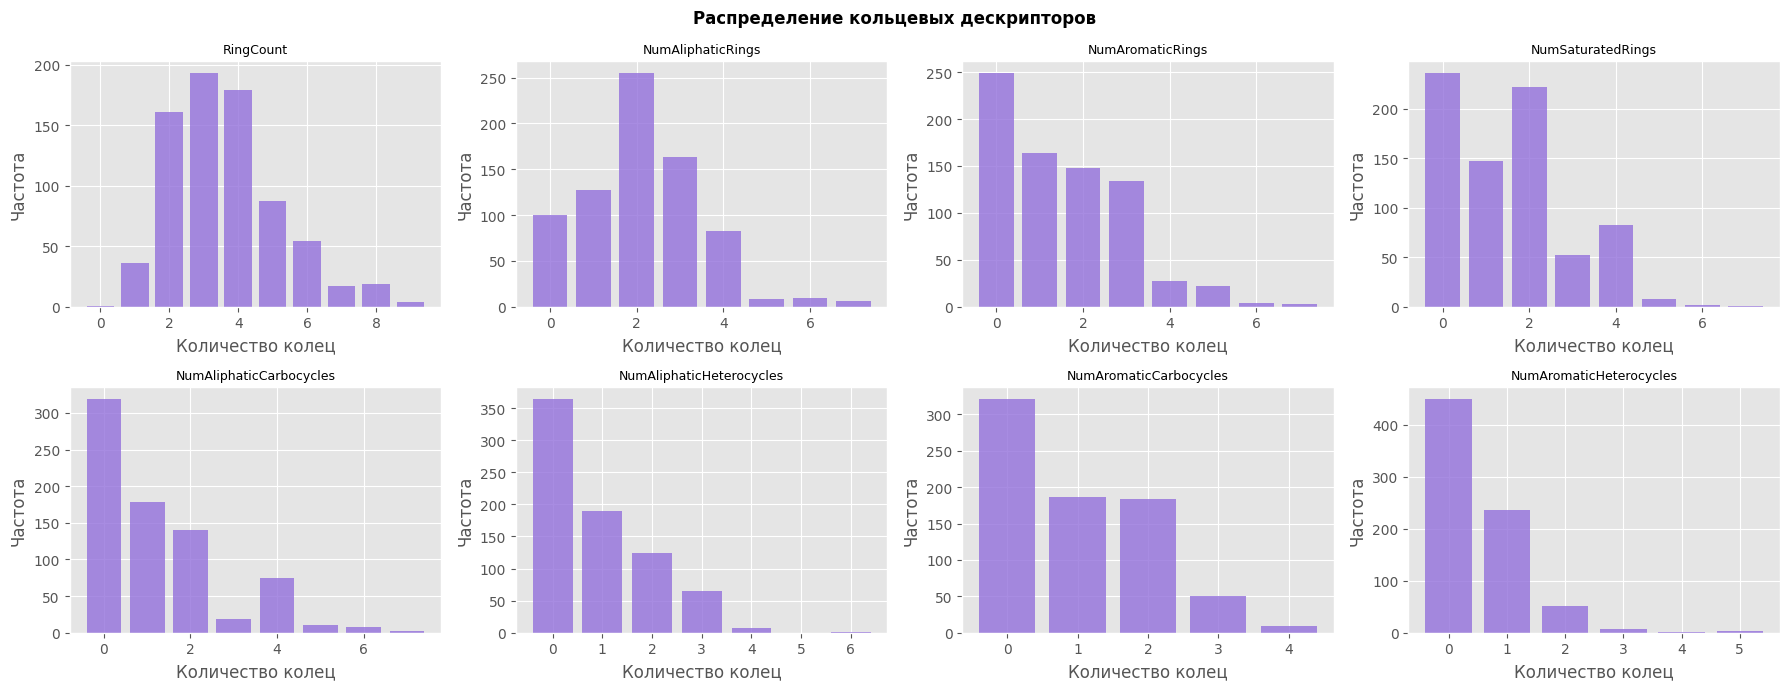

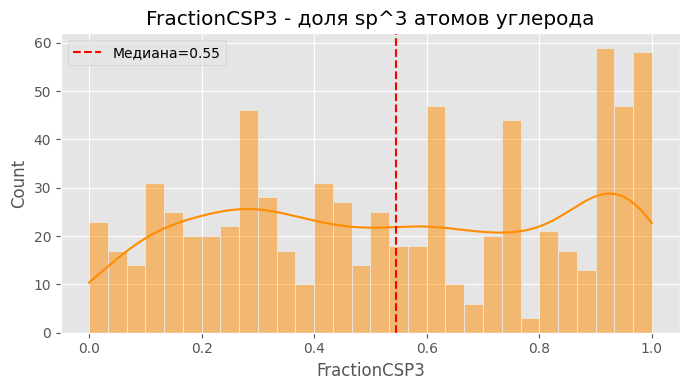

FractionCSP3: mean=0.542, median=0.545


In [16]:
ring_feats = [
 'RingCount',
 'NumAliphaticRings', 'NumAromaticRings', 'NumSaturatedRings',
 'NumAliphaticCarbocycles', 'NumAliphaticHeterocycles',
 'NumAromaticCarbocycles', 'NumAromaticHeterocycles',
]

fig, axes = plt.subplots(2, 4, figsize=(18, 7))
axes = axes.flatten()
for i, feat in enumerate(ring_feats):
 ax = axes[i]
 vc = train[feat].value_counts().sort_index()
 ax.bar(vc.index, vc.values, color='mediumpurple', alpha=0.8)
 ax.set_title(feat, fontsize=9)
 ax.set_xlabel('Количество колец')
 ax.set_ylabel('Частота')

plt.suptitle('Распределение кольцевых дескрипторов', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# FractionCSP3
fig, ax = plt.subplots(figsize=(7, 4))
sns.histplot(train['FractionCSP3'], kde=True, bins=30, color='darkorange', ax=ax)
ax.axvline(train['FractionCSP3'].median(), color='red', linestyle='--', label=f'Медиана={train["FractionCSP3"].median():.2f}')
ax.set_title('FractionCSP3 - доля sp^3 атомов углерода')
ax.legend()
plt.tight_layout()
plt.show()
print(f'FractionCSP3: mean={train["FractionCSP3"].mean():.3f}, median={train["FractionCSP3"].median():.3f}')

## 17. Детальный анализ Chi и Kappa индексов

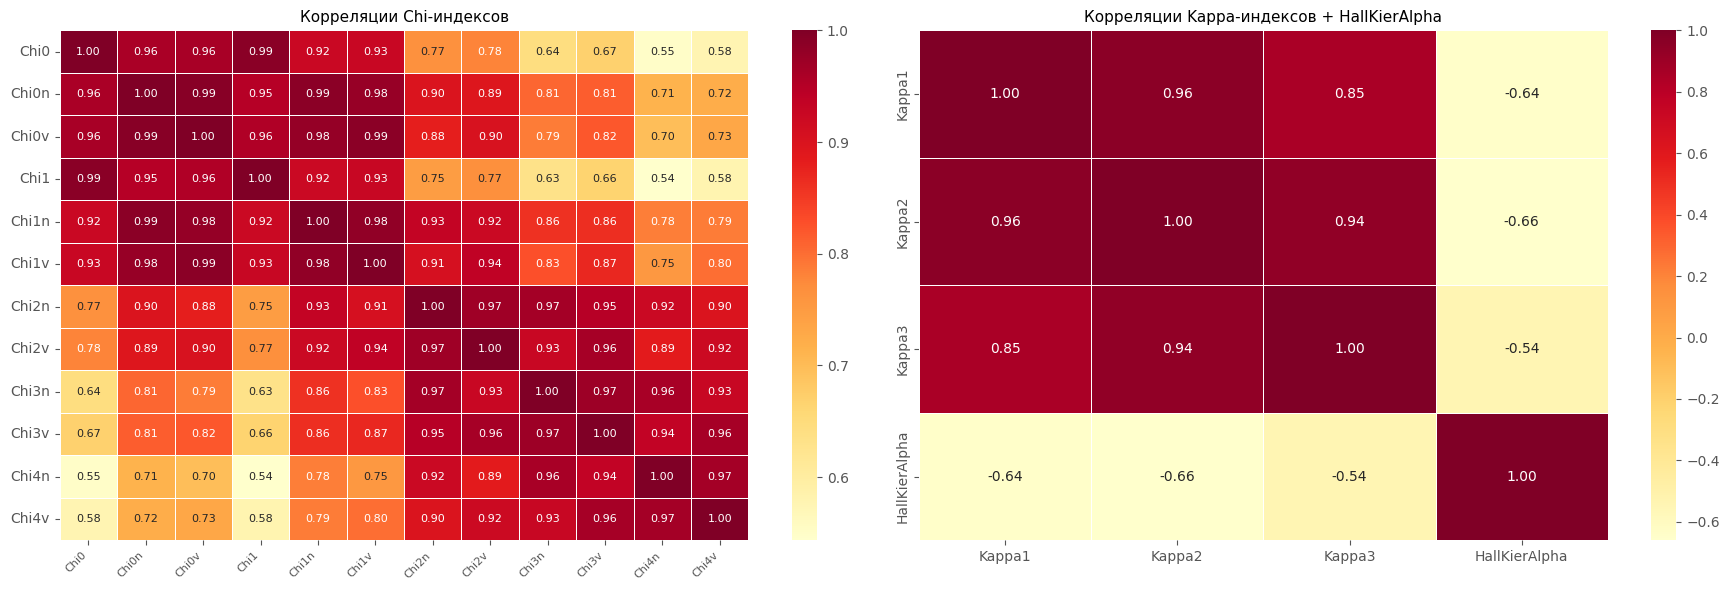

In [17]:
chi_feats = [f for f in FEATURES if f.startswith('Chi')]
kappa_feats = [f for f in FEATURES if f.startswith('Kappa')]

# Chi-корреляции между собой (матрица)
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.heatmap(train[chi_feats].corr(), annot=True, fmt='.2f', cmap='YlOrRd',
 linewidths=0.5, ax=axes[0], annot_kws={'size': 8})
axes[0].set_title('Корреляции Chi-индексов', fontsize=11)
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right', fontsize=8)

sns.heatmap(train[kappa_feats + ['HallKierAlpha']].corr(), annot=True, fmt='.2f',
 cmap='YlOrRd', linewidths=0.5, ax=axes[1], annot_kws={'size': 10})
axes[1].set_title('Корреляции Kappa-индексов + HallKierAlpha', fontsize=11)

plt.tight_layout()
plt.show()

## 18. Ipc vs AvgIpc и BertzCT

Ipc и BertzCT - меры молекулярной сложности. Проверим, насколько они скоррелированы между собой и с таргетами.

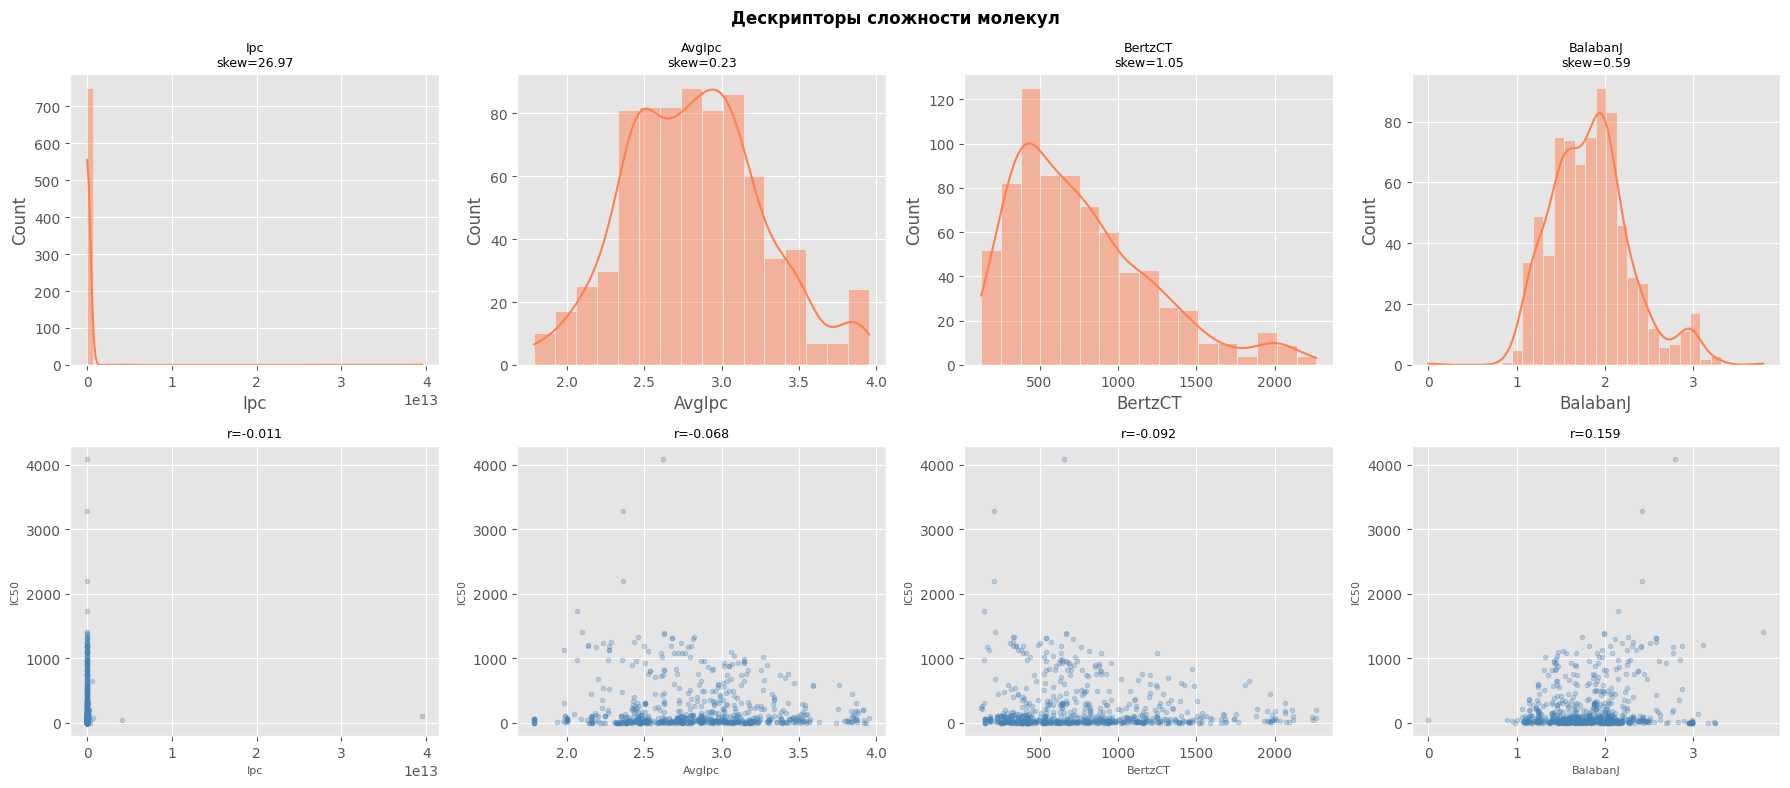


Корреляция между дескрипторами сложности:
             Ipc  AvgIpc  BertzCT  BalabanJ
Ipc       1.0000  0.0447   0.1294   -0.0658
AvgIpc    0.0447  1.0000   0.7911   -0.6229
BertzCT   0.1294  0.7911   1.0000   -0.5052
BalabanJ -0.0658 -0.6229  -0.5052    1.0000


In [18]:
complexity_feats = ['Ipc', 'AvgIpc', 'BertzCT', 'BalabanJ']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for j, feat in enumerate(complexity_feats):
 # Гистограмма
 ax = axes[0, j]
 data = train[feat].dropna()
 sns.histplot(data, kde=True, ax=ax, color='coral')
 ax.set_title(f'{feat}\nskew={data.skew():.2f}', fontsize=9)
 # vs BertzCT (контекст сложности)
 ax2 = axes[1, j]
 ax2.scatter(train[feat], train['IC50'], alpha=0.3, s=12, color='steelblue')
 r_val = train[[feat, 'IC50']].corr().iloc[0, 1]
 ax2.set_xlabel(feat, fontsize=8)
 ax2.set_ylabel('IC50', fontsize=8)
 ax2.set_title(f'r={r_val:.3f}', fontsize=9)

plt.suptitle('Дескрипторы сложности молекул', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nКорреляция между дескрипторами сложности:')
print(train[complexity_feats].corr().round(4))

## 19. Целевые переменные: распределение и взаимосвязь

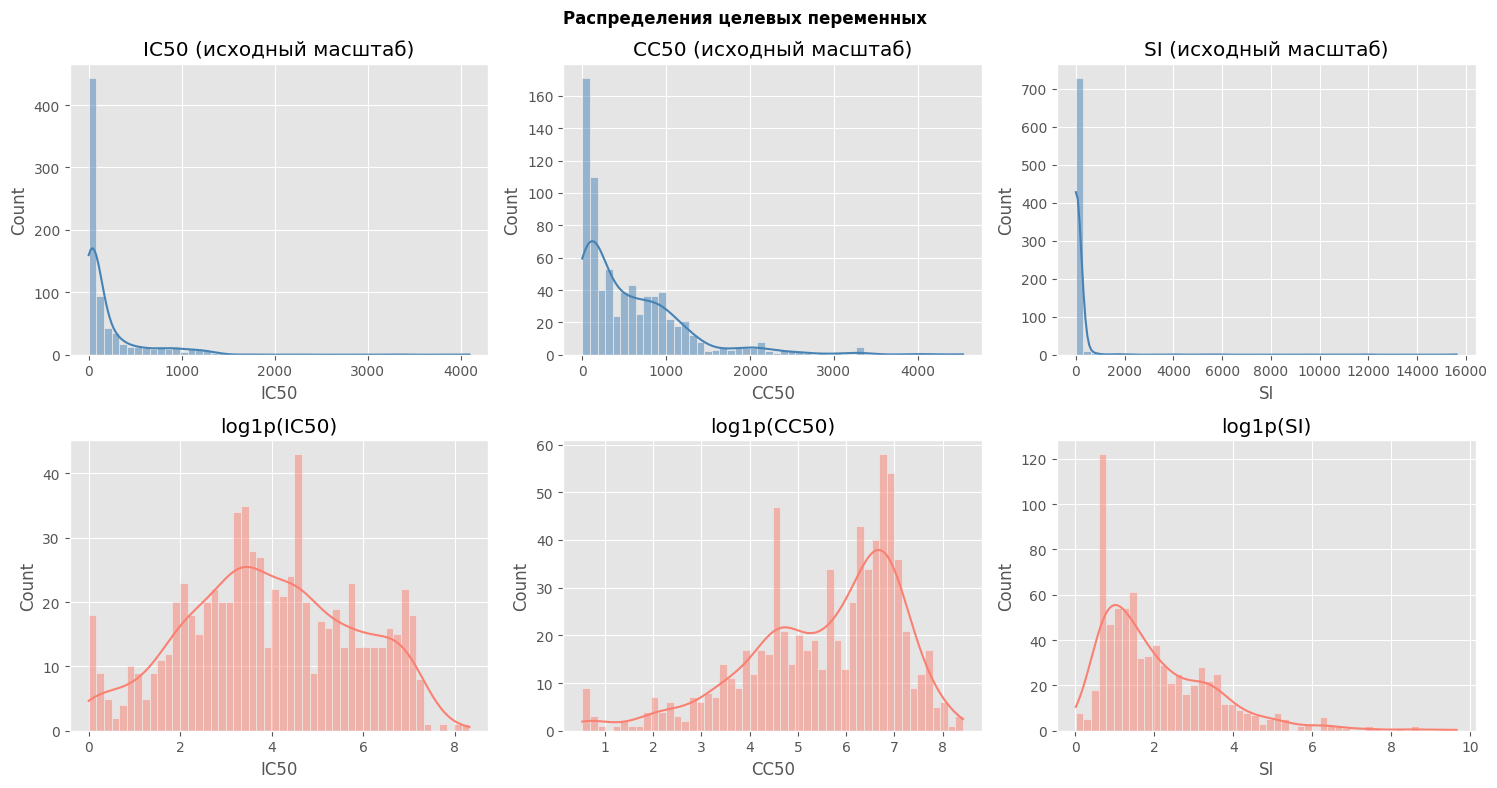

Корреляции между таргетами:
        IC50    CC50      SI
IC50  1.0000  0.4704 -0.0605
CC50  0.4704  1.0000 -0.0057
SI   -0.0605 -0.0057  1.0000


In [19]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for i, col in enumerate(TARGETS):
 sns.histplot(train[col], bins=50, ax=axes[0, i], kde=True, color='steelblue')
 axes[0, i].set_title(f'{col} (исходный масштаб)')
 sns.histplot(np.log1p(train[col].clip(lower=0)), bins=50, ax=axes[1, i], kde=True, color='salmon')
 axes[1, i].set_title(f'log1p({col})')
plt.suptitle('Распределения целевых переменных', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# Корреляции между таргетами
print('Корреляции между таргетами:')
print(train[TARGETS].corr().round(4))

## 20. Итоговый рейтинг признаков

Комбинированный рейтинг по Пирсону + Спирмену + взаимной информации.

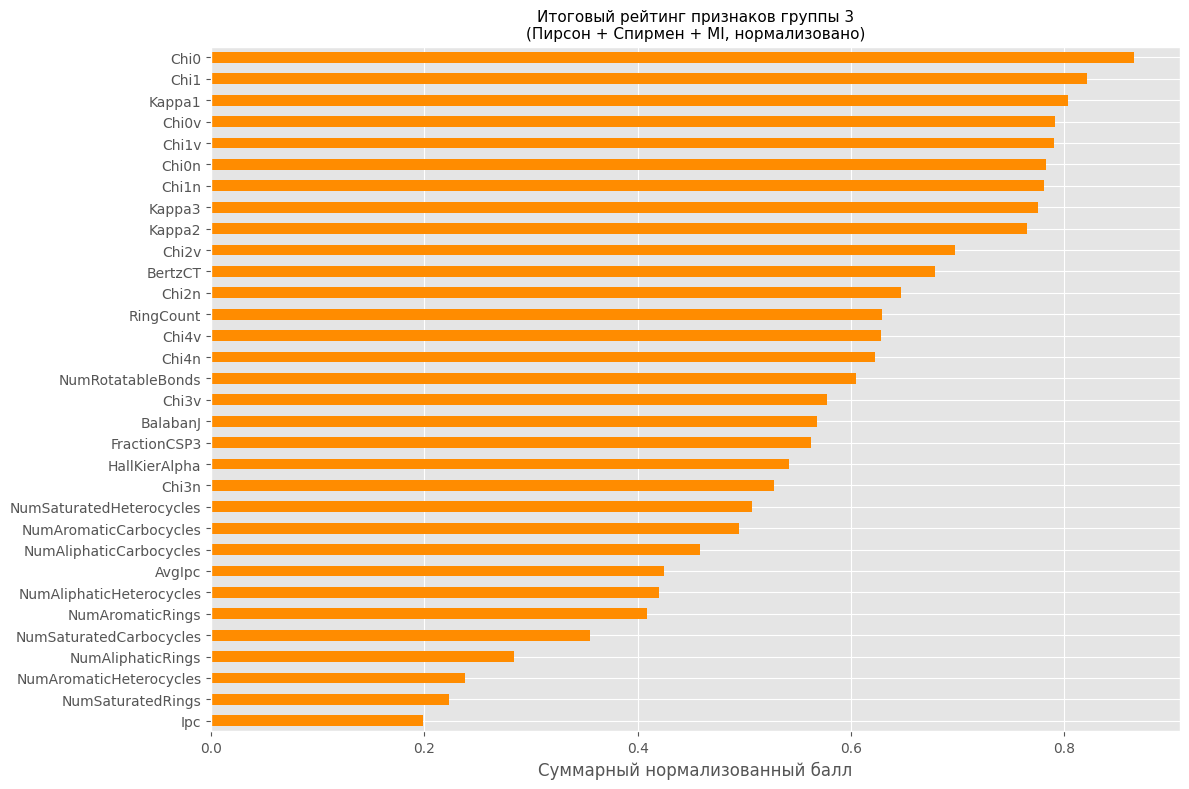


Топ-10 наиболее информативных признаков группы 3:
        |r| Пирсон  |ρ| Спирмен  Итоговый балл
Chi0        0.1632       0.1535         0.8650
Chi1        0.1669       0.1454         0.8212
Kappa1      0.1576       0.1621         0.8033
Chi0v       0.1738       0.1486         0.7914
Chi1v       0.1813       0.1444         0.7900
Chi0n       0.1716       0.1509         0.7828
Chi1n       0.1795       0.1464         0.7808
Kappa3      0.1618       0.1643         0.7751
Kappa2      0.1603       0.1666         0.7645
Chi2v       0.1827       0.1248         0.6973


In [20]:
# Средняя |r| Пирсон
pearson_mean = corr_all[TARGETS].loc[FEATURES].abs().mean(axis=1)
# Средняя |ρ| Спирмен
spearman_mean = spearman_corr[TARGETS].loc[FEATURES].abs().mean(axis=1)
# Средняя MI
mi_mean = mi_df['mean_MI']

# Нормализуем каждый рейтинг от 0 до 1 и усредняем
def normalize(s):
 return (s - s.min()) / (s.max() - s.min() + 1e-10)

rank_df = pd.DataFrame({
 '|r| Пирсон': pearson_mean,
 '|ρ| Спирмен': spearman_mean,
 'MI (норм)': normalize(mi_mean),
})
rank_df['Итоговый балл'] = (
 normalize(rank_df['|r| Пирсон']) +
 normalize(rank_df['|ρ| Спирмен']) +
 normalize(rank_df['MI (норм)'])
) / 3
rank_df = rank_df.sort_values('Итоговый балл', ascending=False)

fig, ax = plt.subplots(figsize=(12, 8))
rank_df['Итоговый балл'].sort_values().plot(kind='barh', ax=ax, color='darkorange')
ax.set_title('Итоговый рейтинг признаков группы 3\n(Пирсон + Спирмен + MI, нормализовано)', fontsize=11)
ax.set_xlabel('Суммарный нормализованный балл')
plt.tight_layout()
plt.show()

print('\nТоп-10 наиболее информативных признаков группы 3:')
print(rank_df[['|r| Пирсон', '|ρ| Спирмен', 'Итоговый балл']].head(10).round(4).to_string())

## 21. Выводы

### Качество данных
- Пропуски: отсутствуют во всех 32 признаках группы - данные полные.
- Выбросы (IQR): наибольшее число выбросов у Ipc (skew=26.97, диапазон до 3.95×10^13), NumRotatableBonds (skew=2.17), NumAromaticHeterocycles, Kappa3. Это характерно для хим. дескрипторов с широким диапазоном молекулярной сложности.
- Константных/почти константных признаков: нет.

### Распределения
- Ipc - аномальная асимметрия (skew ≈ 27), диапазон от 107 до 3.95×10^13. Обязательна log-трансформация.
- BertzCT, NumRotatableBonds - умеренная правосторонняя асимметрия, log1p улучшает форму распределения.
- Chi-индексы - распределены близко к нормальному, умеренно асимметрично.
- FractionCSP3 - непрерывный [0, 1], медиана 0.56, бимодальное распределение (пик у 0 у ароматических и 0.7–1.0 у насыщенных молекул).
- Кольцевые дескрипторы - дискретные счётчики (0–9), преобладают значения 1–4.

### Мультиколлинеарность
- Выявлено 22 пары с |r| > 0.95 - критически высокая мультиколлинеарность среди Chi-индексов.
- Самые сильные дубликаты: Chi0n–Chi0v (r=0.993), Chi0–Chi1 (r=0.991), Chi0–Kappa1 (r=0.980).
- Chi0n, Chi0v, Chi1n, Chi1v практически идентичны - несут почти одинаковую информацию.
- Рекомендуется оставить по одному представителю каждого уровня или применить PCA.

### Связь с таргетами
- IC50: лучшие корреляторы - Chi2n (r=0.225), Chi2v (r=0.220), Chi4v (r=0.214). Связь умеренная.
- CC50: лучшие - Chi0 (r=0.305), Kappa1 (r=0.305), Kappa2 (r=0.303), Chi1 (r=0.302). Связь слабая–умеренная.
- SI: лучший - BalabanJ (r=0.188), RingCount (r=0.142). Связь слабая.
- По взаимной информации (MI): Chi0, Chi1, Kappa1 наиболее информативны для CC50 (нелинейные зависимости). Для SI уникально важны FractionCSP3 и HallKierAlpha.

### Рекомендации для моделирования
1. Применить np.log1p к Ipc перед подачей в модель; рассмотреть то же для BertzCT и BalabanJ.
2. Из Chi-индексов достаточно оставить один вариант каждого уровня, например Chi0v, Chi1v, Chi2v, Chi3v, Chi4v, или применить PCA на всю подгруппу.
3. Кольцевые дескрипторы (RingCount, NumAromaticRings) можно рассматривать как ординальные/категориальные признаки.
4. FractionCSP3 и BalabanJ несут уникальную информацию для предсказания SI - стоит сохранить оба.
5. Таргеты IC50 и CC50 правоскошены - рекомендуется обучать модели на log1p(IC50) и log1p(CC50).
